In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve)
from utils import TARGET, basic_report

test_df = pd.read_csv("/content/test.csv")
basic_report(test_df)
test_df.head()

shape: (223, 35)

nulls:
 Series([], dtype: int64)

dupes: 0

dtypes:
 Age                         float64
Attrition                    object
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome              int64
Education                     int64
EducationField               object
EmployeeCount                 int64
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                       object
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                      object
JobSatisfaction               int64
MaritalStatus                object
MonthlyIncome                object
MonthlyRate                   int64
NumCompaniesWorked          float64
Over18                       object
OverTime                     object
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction     

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,32.0,No,Travel_Frequently,585,Research & Development,10,3,Life Sciences,1,1720,...,1,80,1.0,10.0,3.0,2,5.0,2.0,1.0,3.0
1,35.0,No,Non-Travel,1180,Research & Development,2,2,Medical,1,1804,...,3,80,1.0,15.0,4.5,3,7.0,7.0,1.0,7.0
2,42.0,No,Travel_Rarely,557,Research & Development,18,4,Life Sciences,1,1998,...,3,80,1.0,9.0,3.0,2,4.0,3.0,1.0,2.0
3,47.0,No,Travel_Rarely,1001,Research & Development,4,3,Life Sciences,1,1827,...,3,80,1.0,28.0,4.0,3,20.5,11.0,7.5,10.0
4,37.0,No,Travel_Rarely,367,Research & Development,25,2,Medical,1,1161,...,3,80,2.0,9.0,2.0,3,6.0,2.0,1.0,3.0


In [7]:
df = test_df.copy()
df[TARGET] = df[TARGET].map({"Yes": 1, "No": 0})

# Clean MonthlyIncome to match training preprocessing
df["MonthlyIncome"] = (
    df["MonthlyIncome"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["MonthlyIncome"] = pd.to_numeric(df["MonthlyIncome"])
cat_cols = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [8]:
model = joblib.load("/content/attrition_model.pkl")
model_columns = joblib.load("/content/model_columns.pkl")

In [9]:
df = df.reindex(columns=model_columns + [TARGET], fill_value=0)
X_test = df[model_columns]
y_test = df[TARGET]

In [10]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print()
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

Accuracy: 0.852017937219731
ROC AUC: 0.747112462006079

              precision    recall  f1-score   support

          No       0.86      0.99      0.92       188
         Yes       0.67      0.11      0.20        35

    accuracy                           0.85       223
   macro avg       0.76      0.55      0.56       223
weighted avg       0.83      0.85      0.80       223



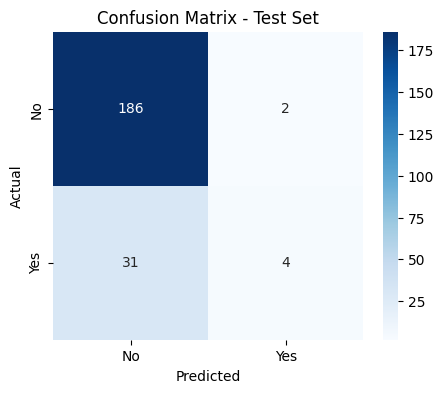

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No","Yes"],
    yticklabels=["No","Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

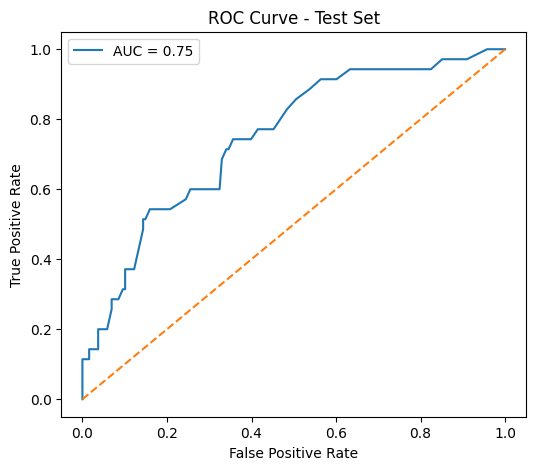

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}"
)

plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.savefig("roc_curve.png", bbox_inches="tight")
plt.show()

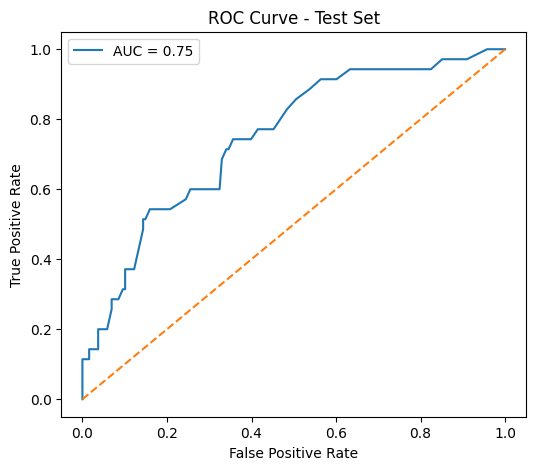

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}"
)

plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.savefig("roc_curve.png", bbox_inches="tight")
plt.show()